# Post-adaptation hyperparameter sweep - analysis

Reads `ProVoice.training_scripts.sweep_population_hparams --adapt-eval`, whose output
lives in its **own directory** (default `results/pop_pipeline_adapt/<stage>`), separate
from the unadapted sweep in `results/pop_pipeline`.

## The question this notebook answers

Not "which configuration wins". It is:

> **Does selecting on the post-adaptation score change what we ship, and is it a
> better-resolved instrument than the unadapted score?**

The population model is never served unadapted - both study arms fine-tune a head on
top of it - so unadapted held-out-driver set-MAE is a proxy for a quantity the design
has already declared is not the objective. `xlstm_maml.evaluate_adaptation` and
`sweep_l2sp_tau` both already select on their own post-adaptation numbers; running the
population sweep this way makes stage 1 agree with them.

There is also an empirical reason. On the unadapted criterion the sweep came back
**NOT RESOLVABLE** for `corn_w10` (configuration spread 0.023 against 2 SE = 0.026),
so the winner was effectively decided by the most-regularized tie-break rather than by
the data.

## What each run writes

Every epoch, for every validation driver, the head is adapted on that driver's first K
labels (their true session prefix, through the deployed `head_adapt` call) and scored
on everything after. The aggregate is the mean over K **within** a driver, then the
mean across drivers - drivers contribute 94-136 segments, so a flat mean over cells
would weight the long sessions.

| column | meaning |
|---|---|
| `smoothed_best_set_mae` | UNADAPTED score at the unadapted-selected epoch |
| `adapt_at_best` | ADAPTED score at the **unadapted**-selected epoch |
| `smoothed_best_adapt_mae` | ADAPTED score at the **adapted**-selected epoch |
| `best_epoch_1se` / `best_epoch_1se_adapt` | E\* under each criterion |
| `adapt_mae_k<K>` | per-K cross-section at the adapt-selected epoch |
| `init_adapt_set_mae` | UNTRAINED backbone + adapted head |

## Three floors, and picking the right one

An adapted score must never be read against the global constant. Once the system has
seen the driver's first K labels, "always predict this driver's favourite level" is
free, and that is the floor that binds - `adapt_fold_baseline` computes it on the same
support, matched K grid and all.

`init_adapt_set_mae` is the second reference and the more interesting one: an untrained
xLSTM is a random-feature reservoir, and a reservoir plus an adapted head is a strong
baseline. **If the trained model's adapted score does not beat it, training the backbone
contributes nothing that per-driver adaptation can use** - whatever the unadapted curve
does. This is the random-backbone control from `docs/embedding_informativeness.md`,
obtained for one extra evaluation rather than a separate experiment.

In [1]:
import sys, pathlib, warnings, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# The notebook lives in src/ProVoice/training_analysis/; walk up to find src/.
_SRC = pathlib.Path.cwd()
for _ in range(6):
    if (_SRC / "ProVoice").is_dir():
        break
    _SRC = _SRC.parent
sys.path.insert(0, str(_SRC))

# Imported, not re-implemented: any curve recomputed here must use the SAME
# smoothing and 1-SE rule the sweep ranked with, or it answers a different
# question. reduce_curve is the shared reduction for BOTH criteria.
from ProVoice.training_scripts.sweep_population_hparams import (
    SMOOTH_WINDOW, adapt_fold_baseline, load_segment_labels, reduce_curve, smooth,
)

%matplotlib inline
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------- configuration
ADAPT_BASE = pathlib.Path("../../../results/pop_pipeline_adapt")
PLAIN_BASE = pathlib.Path("../../../results/pop_pipeline")   # the unadapted sweep
LABELS_JSONL = pathlib.Path("../../../data/labeled_data.jsonl")
MIN_SELECT_EPOCH = 3          # must match what the sweep ran with
STAGE = "corn_w10"            # which stage directory to analyse

print(f"ADAPT_BASE = {ADAPT_BASE.resolve()}")
for b, tag in ((ADAPT_BASE, "adapted"), (PLAIN_BASE, "unadapted")):
    p = b / STAGE / "sweep_results.csv"
    n = (sum(1 for _ in p.open()) - 1) if p.exists() else 0
    print(f"  {tag:<10} {STAGE:<10} {'found' if p.exists() else 'MISSING':<8} {n:>4} rows")

ADAPT_BASE = C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\results\pop_pipeline_adapt
  adapted    corn_w10   found      36 rows
  unadapted  corn_w10   found     180 rows


In [2]:
# ------------------------------------------------------------------- loading

def load(base: pathlib.Path, stage: str = STAGE) -> pd.DataFrame:
    """One sweep's results CSV, or an empty frame."""
    p = base / stage / "sweep_results.csv"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    if df.empty:
        return df
    df["config"] = ("drop=" + df["dropout"].astype(str)
                    + " lr=" + df["lr"].map(lambda x: f"{x:g}"))
    return df


def k_columns(df: pd.DataFrame) -> list:
    """The per-K MAE columns present, in numeric K order.

    Discovered from the frame rather than hard-coded: the grid is a CLI argument
    (--adapt-k), so a fixed list would silently drop a K or invent one.
    """
    ks = [(int(re.search(r"_k(\d+)$", c).group(1)), c)
          for c in df.columns if re.match(r"^adapt_mae_k\d+$", c)]
    return [c for _, c in sorted(ks)]


def k_of(col: str) -> int:
    return int(re.search(r"_k(\d+)$", col).group(1))


def curves(base: pathlib.Path, stage: str = STAGE) -> pd.DataFrame:
    """Every retained per-epoch curve, tagged with its (config, fold, seed)."""
    d = base / stage / "runs"
    if not d.exists():
        d = base / stage
    out = []
    for f in sorted(d.glob("metrics_*.csv")):
        try:
            c = pd.read_csv(f)
        except Exception:
            continue
        if c.empty:
            continue
        tag = f.stem[len("metrics_"):]
        try:
            c["dropout"] = float(tag.split("_lr")[0][1:])
            rest = tag.split("_lr")[1]
            c["lr"] = float(rest.split("_f")[0])
            c["val_pids"] = rest.split("_f")[1].split("_s")[0].replace("-", "|")
            c["seed"] = int(rest.split("_s")[1].split("_")[0])
        except (IndexError, ValueError):
            continue
        c["config"] = "drop=" + str(c["dropout"].iloc[0]) + " lr=" + f"{c['lr'].iloc[0]:g}"
        # embed_fcd lives in the TAG SUFFIX (`..._fcd`), not in the curve file, and
        # it is a separate column rather than part of `config` on purpose: the
        # tables join against ADF["config"], which is (dropout, lr) only, so
        # folding it in here would break every one of them.
        c["embed_fcd"] = int(tag.endswith("_fcd"))
        c["tag"] = tag
        out.append(c)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def _fmt(df: pd.DataFrame, cols) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df:
            df[c] = df[c].astype(float).round(3)
    return df


ADF = load(ADAPT_BASE)
PDF = load(PLAIN_BASE)
KCOLS = k_columns(ADF)
print(f"adapted runs: {len(ADF)} | unadapted runs: {len(PDF)} | per-K columns: "
      f"{[k_of(c) for c in KCOLS]}")

adapted runs: 36 | unadapted runs: 180 | per-K columns: [5, 10, 20, 30, 40, 50, 60]


In [3]:
# ------------------- Table 1: does the criterion change the decision?

def table_criterion_gap(df: pd.DataFrame) -> pd.DataFrame:
    """THE headline table. Per configuration, what selecting on the wrong curve costs.

    `adapt_at_best` is the adapted score at the epoch the UNADAPTED curve picks;
    `smoothed_best_adapt_mae` is the adapted score at the epoch the ADAPTED curve
    picks. Both describe the same runs - only the epoch differs.

    `cost_of_wrong_epoch` is their difference, in set-MAE. It is the entire
    justification for the switch: near zero means ranking post-adaptation is
    cosmetic and the cheaper criterion is fine; clearly positive means E* chosen
    on the unadapted curve lands in the wrong place, and stage 2 - which trains
    for E* with no validation set of its own - has no way to notice.
    """
    if df.empty or "adapt_at_best" not in df:
        return pd.DataFrame()
    g = df.groupby("config", as_index=False).agg(
        n=("seed", "size"),
        unadapted=("smoothed_best_set_mae", "mean"),
        adapted_at_unadapted_epoch=("adapt_at_best", "mean"),
        adapted=("smoothed_best_adapt_mae", "mean"),
        adapted_sd=("smoothed_best_adapt_mae", "std"),
        E_star_unadapted=("best_epoch_1se", "median"),
        E_star_adapted=("best_epoch_1se_adapt", "median"),
        init_adapted=("init_adapt_set_mae", "mean"),
    )
    g["adapted_se"] = g["adapted_sd"] / np.sqrt(g["n"].clip(lower=1))
    g["cost_of_wrong_epoch"] = g["adapted_at_unadapted_epoch"] - g["adapted"]
    g["E_star_shift"] = g["E_star_adapted"] - g["E_star_unadapted"]
    # Negative = the trained backbone helps adaptation over a random one.
    g["vs_init_adapted"] = g["adapted"] - g["init_adapted"]
    cols = ["config", "n", "unadapted", "adapted", "adapted_se",
            "adapted_at_unadapted_epoch", "cost_of_wrong_epoch",
            "E_star_unadapted", "E_star_adapted", "E_star_shift",
            "init_adapted", "vs_init_adapted"]
    return _fmt(g[cols].sort_values("adapted").reset_index(drop=True),
                ["unadapted", "adapted", "adapted_se", "adapted_at_unadapted_epoch",
                 "cost_of_wrong_epoch", "init_adapted", "vs_init_adapted"])


def table_rank_agreement(df: pd.DataFrame) -> pd.DataFrame:
    """Would the two criteria ship the same configuration?

    Ranks are over configuration MEANS. Agreement here is the practical
    question - a large `cost_of_wrong_epoch` still would not matter if both
    criteria happened to crown the same config at the same epoch.
    """
    if df.empty or "smoothed_best_adapt_mae" not in df:
        return pd.DataFrame()
    g = df.groupby("config").agg(unadapted=("smoothed_best_set_mae", "mean"),
                                 adapted=("smoothed_best_adapt_mae", "mean"))
    g["rank_unadapted"] = g["unadapted"].rank().astype(int)
    g["rank_adapted"] = g["adapted"].rank().astype(int)
    g["rank_change"] = g["rank_adapted"] - g["rank_unadapted"]
    g = g.reset_index().sort_values("rank_adapted")
    spear = g["rank_unadapted"].corr(g["rank_adapted"], method="spearman")
    print(f"Spearman rank correlation between criteria: {spear:.3f}"
          f"   (1.0 = identical ordering)")
    w_un = g.loc[g["rank_unadapted"].idxmin(), "config"]
    w_ad = g.loc[g["rank_adapted"].idxmin(), "config"]
    print(f"winner unadapted: {w_un}   |   winner adapted: {w_ad}"
          f"   -> {'SAME' if w_un == w_ad else 'DIFFERENT'}")
    return _fmt(g, ["unadapted", "adapted"])


if ADF.empty:
    print("(adapted sweep has not produced results yet)")
else:
    display(Markdown("**Table 1 - what selecting on the wrong curve costs**"))
    display(table_criterion_gap(ADF))
    display(Markdown("**Table 2 - rank agreement between the two criteria**"))
    display(table_rank_agreement(ADF))

**Table 1 - what selecting on the wrong curve costs**

,config,n,unadapted,adapted,adapted_se,adapted_at_unadapted_epoch,cost_of_wrong_epoch,E_star_unadapted,E_star_adapted,E_star_shift,init_adapted,vs_init_adapted
0,drop=0.15 lr=0.001,36,1.539,1.015,0.042,1.065,0.05,5.0,4.0,-1.0,1.158,-0.143


**Table 2 - rank agreement between the two criteria**

Spearman rank correlation between criteria: nan   (1.0 = identical ordering)
winner unadapted: drop=0.15 lr=0.001   |   winner adapted: drop=0.15 lr=0.001   -> SAME


,config,unadapted,adapted,rank_unadapted,rank_adapted,rank_change
0,drop=0.15 lr=0.001,1.539,1.015,1,1,0


In [4]:
# ------------------ Table 3: is the adapted criterion better RESOLVED?

def table_variance(df: pd.DataFrame, metric: str) -> dict:
    """Can this criterion separate configurations at all?

    Same decomposition the unadapted analysis uses, so the two are directly
    comparable: fold SD (expected to dominate - folds differ in intrinsic
    difficulty), seed SD (a single run's noise floor), and the configuration
    spread that the sweep exists to measure. The verdict compares the spread
    against 2 SE of a configuration mean.

    This is the second half of the case for switching. The unadapted criterion
    returned NOT RESOLVABLE on corn_w10; if the adapted one resolves, the switch
    buys a usable instrument rather than only a better-aimed one.
    """
    if df.empty or metric not in df:
        return {}
    per_cfg = df.groupby("config")[metric].mean()
    seed_sd = float(df.groupby(["config", "val_pids"])[metric].std(ddof=1).mean())
    n_per = float(df.groupby("config").size().mean())
    cfg_se = seed_sd / np.sqrt(max(n_per, 1.0))
    spread = float(per_cfg.max() - per_cfg.min()) if len(per_cfg) > 1 else np.nan
    ok = np.isfinite(spread) and np.isfinite(cfg_se) and cfg_se > 0 and spread > 2 * cfg_se
    return {"metric": metric, "n_configs": len(per_cfg), "runs_per_config": round(n_per, 1),
            "fold_sd": round(float(df.groupby("val_pids")[metric].mean().std(ddof=1)), 3)
            if df["val_pids"].nunique() > 1 else np.nan,
            "seed_sd": round(seed_sd, 3),
            "config_spread": round(spread, 3) if np.isfinite(spread) else np.nan,
            "2_SE": round(2 * cfg_se, 3) if np.isfinite(cfg_se) else np.nan,
            "verdict": ("RESOLVABLE" if ok else "NOT RESOLVABLE - take the most "
                                                "regularized config")}


def table_paired(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Every configuration against the best one, PAIRED on (fold, seed).

    Fold difficulty dominates the variance, so an unpaired comparison can call a
    real difference a tie. Every configuration saw the identical (fold, seed)
    cells, so differencing within a cell cancels fold difficulty exactly.
    Descriptive statistic, not a hypothesis test: no multiplicity correction, and
    the cells are not independent across folds.
    """
    if df.empty or metric not in df or df["config"].nunique() < 2:
        return pd.DataFrame()
    wide = df.pivot_table(index=["val_pids", "seed"], columns="config", values=metric)
    ref = wide.mean().idxmin()
    rows = []
    for cfg in wide.columns:
        if cfg == ref:
            continue
        d = (wide[cfg] - wide[ref]).dropna()
        if d.empty:
            continue
        sd = float(d.std(ddof=1)) if len(d) > 1 else np.nan
        se = sd / np.sqrt(len(d)) if np.isfinite(sd) else np.nan
        rows.append({"config": cfg, "vs_reference": ref, "n_pairs": len(d),
                     "delta": float(d.mean()), "delta_se": se,
                     "t": float(d.mean() / se) if se and se > 0 else np.nan})
    out = pd.DataFrame(rows)
    return _fmt(out.sort_values("delta").reset_index(drop=True),
                ["delta", "delta_se", "t"]) if not out.empty else out


if not ADF.empty:
    rows = [table_variance(ADF, "smoothed_best_set_mae"),
            table_variance(ADF, "smoothed_best_adapt_mae")]
    display(Markdown("**Table 3 - resolvability, both criteria on the same runs**"))
    display(pd.DataFrame([r for r in rows if r]))
    display(Markdown("**Table 4 - paired configuration comparison on the ADAPTED metric**"))
    display(table_paired(ADF, "smoothed_best_adapt_mae"))

**Table 3 - resolvability, both criteria on the same runs**

,metric,n_configs,runs_per_config,fold_sd,seed_sd,config_spread,2_SE,verdict
0,smoothed_best_set_mae,1,36.0,0.166,0.057,NaN,0.019,NOT RESOLVABLE - take the most regularized config
1,smoothed_best_adapt_mae,1,36.0,0.269,0.040,NaN,0.013,NOT RESOLVABLE - take the most regularized config


**Table 4 - paired configuration comparison on the ADAPTED metric**

""


**Table 5 - per-K cross-section**

,config,K=5,K=10,K=20,K=30,K=40,K=50,K=60,mean(K)
0,drop=0.15 lr=0.001,1.205,1.133,1.086,1.04,0.958,0.912,0.83,1.015


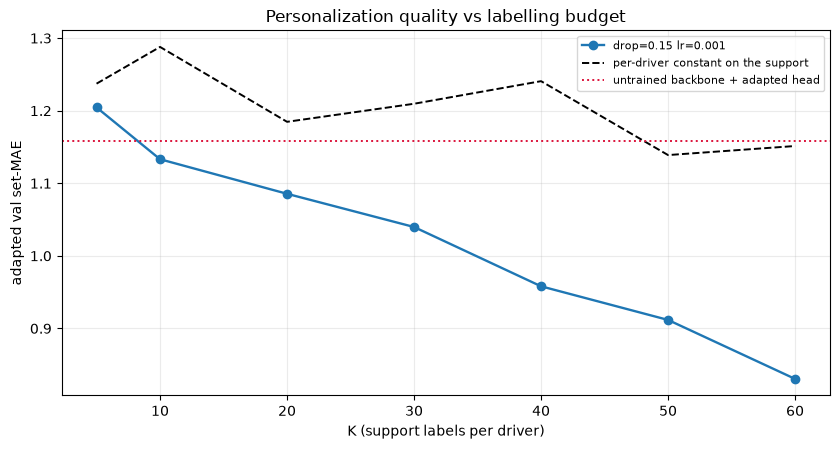

In [5]:
# ---------------------- Table 5 + plot: the quality-vs-K curve

def table_by_k(df: pd.DataFrame) -> pd.DataFrame:
    """Per-K cross-section at each configuration's adapt-selected epoch.

    The mean over K is what RANKS configurations, but the live study varies K,
    so a configuration that wins on the mean while losing at small K is the wrong
    one to ship. Only this table can show that; the aggregate cannot.

    Values are read at the adapt-selected epoch, NOT at each K's own best epoch -
    the run ships one epoch, so the K curve has to be that epoch's cross-section
    rather than a model that never existed.
    """
    if df.empty or not KCOLS:
        return pd.DataFrame()
    g = df.groupby("config")[KCOLS].mean()
    g.columns = [f"K={k_of(c)}" for c in g.columns]
    g["mean(K)"] = df.groupby("config")["smoothed_best_adapt_mae"].mean()
    return _fmt(g.reset_index(), [c for c in g.columns])


def plot_k_curve(df: pd.DataFrame, labels_path: pathlib.Path = LABELS_JSONL):
    """Quality vs K per configuration, with the per-driver constant floor drawn in.

    The floor is recomputed at EACH K from the labels alone (`adapt_fold_baseline`)
    - it is the constant a driver's own first K labels already buy, and it moves
    with K. Plotting an adapted curve against a single flat global constant would
    compare two different games at every point.
    """
    if df.empty or not KCOLS:
        print("(no per-K columns)")
        return
    ks = [k_of(c) for c in KCOLS]
    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    for cfg, g in df.groupby("config"):
        ax.plot(ks, [g[c].mean() for c in KCOLS], marker="o", lw=1.7, label=cfg)

    floors = []
    if labels_path.exists():
        try:
            lab = load_segment_labels(labels_path)
            folds = sorted({v for v in df["val_pids"].dropna().unique()})
            for k in ks:
                per_fold = [adapt_fold_baseline(lab, [x for x in f.split("|") if x], [k])
                            for f in folds]
                floors.append(float(np.nanmean(per_fold)))
            ax.plot(ks, floors, ls="--", c="k", lw=1.4,
                    label="per-driver constant on the support")
        except Exception as exc:
            print(f"(floor unavailable: {exc})")

    if "init_adapt_set_mae" in df:
        ax.axhline(float(df["init_adapt_set_mae"].mean()), ls=":", c="crimson", lw=1.4,
                   label="untrained backbone + adapted head")
    ax.set_xlabel("K (support labels per driver)")
    ax.set_ylabel("adapted val set-MAE")
    ax.set_title("Personalization quality vs labelling budget")
    ax.grid(alpha=.25)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


if not ADF.empty:
    display(Markdown("**Table 5 - per-K cross-section**"))
    display(table_by_k(ADF))
    plot_k_curve(ADF)

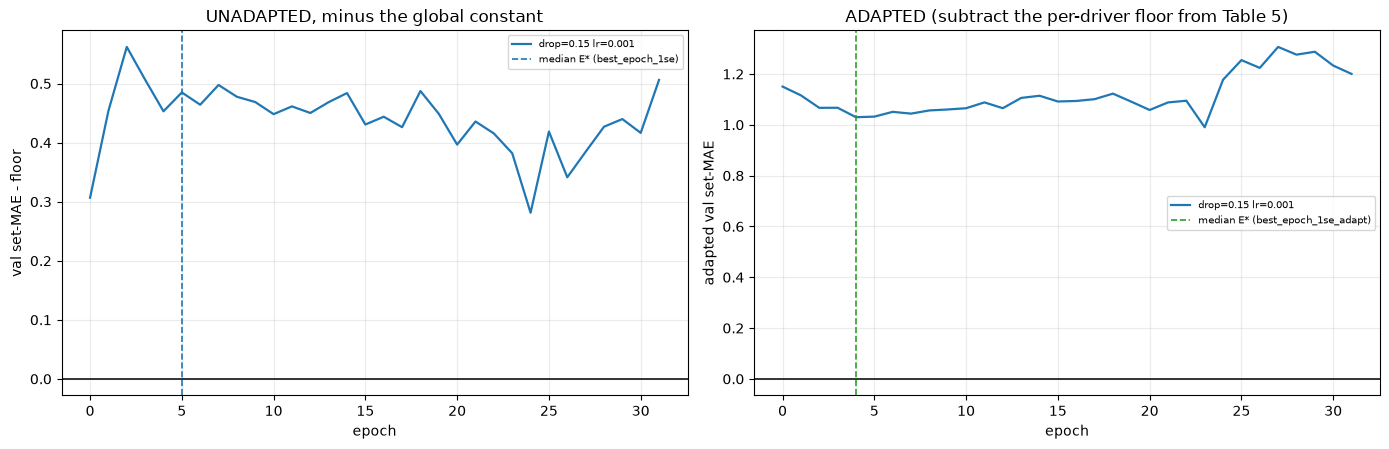

In [6]:
# --------------------- plot: the two validation curves, each vs its own floor

def fold_adapt_floors(df: pd.DataFrame, labels_path: pathlib.Path = LABELS_JSONL):
    """Per-fold per-driver adaptation floor, on the K grid the runs actually used.

    The adapted curve has no floor column of its own -- `pdconst_set_mae` is only
    written under --split-mode within-driver -- so it is recomputed here from the
    labels, the same way `plot_k_curve` does. Keyed by fold, because fold
    difficulty is exactly what subtracting a floor is meant to remove.
    """
    ks = [k_of(c) for c in KCOLS] or [5, 10, 20, 30, 40, 50, 60]
    if not labels_path.exists():
        return {}
    try:
        lab = load_segment_labels(labels_path)
    except Exception as exc:
        print(f"(floor unavailable: {exc})")
        return {}
    return {vp: adapt_fold_baseline(lab, [x for x in vp.split("|") if x], ks)
            for vp in df["val_pids"].dropna().unique()}


def plot_both_curves(base: pathlib.Path = ADAPT_BASE, min_coverage: float = 0.5):
    """Unadapted and adapted validation curves vs epoch, each MINUS its own floor.

    Both panels are floor-subtracted, so y=0 means the same thing on each and the
    black line is readable on both. They are NOT the same floor, and cannot be:
    the unadapted model has never seen the validation drivers, so the global
    constant is the reference; the adapted one has been handed their first K
    labels, which buys the per-driver constant for free. Plotting the adapted
    curve against the global constant would compare two different games.

    Runs are split by embed_fcd, since that is the axis the sweep exists to
    compare and pooling the two arms into one line hides it.

    SURVIVORSHIP. `groupby(epoch).mean()` averages over whichever runs reached
    that epoch, and --patience retires most of them early: on the 36-run sweep,
    36 runs are alive at epoch 10, 11 at epoch 20 and 2 by epoch 25. The late
    tail is therefore a small SELECTED subset -- and a biased one, since those two
    runs were already 0.15 worse than average at epoch 0, which is most of the
    apparent "late overfitting". Everything past `min_coverage` of the runs is
    shaded and excluded from the drawn line rather than silently averaged.
    """
    c = curves(base)
    if c.empty or "adapt_set_mae" not in c:
        print("(no curves with adapt columns)")
        return
    alive = c.groupby("epoch")["tag"].nunique()
    n_runs = c["tag"].nunique()
    ok = alive[alive >= min_coverage * n_runs]
    e_max = int(ok.index.max()) if len(ok) else int(alive.index.max())
    floors = fold_adapt_floors(c)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharex=True)
    for (cfg, efcd), g in c.groupby(["config", "embed_fcd"]):
        lbl = f"{cfg}{' +FCD' if efcd else ''}"
        # LEFT: the global constant, per run, straight from the curve file.
        gl = g.assign(y=g["set_mae"] - g["const_set_mae"])
        # RIGHT: each run minus ITS OWN fold's per-driver adaptation floor, so
        # fold difficulty cancels before averaging instead of after.
        ga = g.assign(y=g["adapt_set_mae"] - g["val_pids"].map(floors))
        for ax, gg in ((axes[0], gl), (axes[1], ga)):
            m = gg[gg["epoch"] <= e_max].groupby("epoch")["y"].mean()
            ax.plot(m.index, m.values, lw=1.6, label=lbl)

    for ax, e_col, c_ in ((axes[0], "best_epoch_1se", "tab:blue"),
                          (axes[1], "best_epoch_1se_adapt", "tab:green")):
        if not ADF.empty and e_col in ADF:
            ax.axvline(float(ADF[e_col].median()), ls="--", c=c_, lw=1.2,
                       label=f"median E* ({e_col})")

    e_all = int(alive.index.max())
    for ax, t in zip(axes, ("UNADAPTED, minus the GLOBAL constant",
                            "ADAPTED, minus the PER-DRIVER floor")):
        ax.axhline(0, c="k", lw=1.1)
        if e_max < e_all:
            ax.axvspan(e_max, e_all, color="0.85", alpha=.6, zorder=0)
            ax.text(e_max + 0.3, ax.get_ylim()[1], f" <{min_coverage:.0%} of runs alive",
                    fontsize=7, va="top", color="0.35")
        ax.set_xlim(0, e_all)
        ax.set_xlabel("epoch")
        ax.set_title(t + "   (below 0 = beats that floor)")
        ax.grid(alpha=.25)
        ax.legend(fontsize=7)
    axes[0].set_ylabel("val set-MAE - global constant")
    axes[1].set_ylabel("adapted val set-MAE - per-driver floor")
    plt.tight_layout()
    plt.show()
    print(f"runs alive: {n_runs} at epoch 0 -> {int(alive.get(e_max, 0))} at epoch "
          f"{e_max} (the last drawn) -> {int(alive.iloc[-1])} at epoch {e_all}")


plot_both_curves()

In [7]:
# ------------------------------------------------- sanity + verdict

def table_sanity(df: pd.DataFrame) -> pd.DataFrame:
    """Did every run actually evaluate what it claims to?

    `adapt_n_cells` counts the surviving (driver, K) cells: a cell is skipped
    when a driver has fewer than K + 20 segments, so a short driver silently
    contributes fewer points. A run with far fewer cells than
    n_drivers x len(K grid) is averaging over a different thing than its
    neighbours, and that is invisible in the aggregate.
    """
    if df.empty:
        return pd.DataFrame()
    cols = [c for c in ("adapt_n_drivers", "val_n", "epochs_run") if c in df]
    g = df.groupby("config")[cols].agg(["min", "mean"])
    return g.round(2)


def verdict(df: pd.DataFrame) -> None:
    """State, in words, whether the switch to the adapted criterion is justified."""
    if df.empty:
        print("(no completed runs)")
        return
    t = table_criterion_gap(df)
    if t.empty:
        print("(no adapted columns - was the sweep run with --adapt-eval?)")
        return
    best = t.iloc[0]
    print(f"BEST CONFIG (adapted): {best['config']}  adapted set-MAE "
          f"{best['adapted']:.3f} +/- {best['adapted_se']:.3f}")
    print(f"  E* : {best['E_star_unadapted']:.0f} (unadapted) -> "
          f"{best['E_star_adapted']:.0f} (adapted)")
    print(f"  cost of selecting on the unadapted curve: "
          f"{best['cost_of_wrong_epoch']:+.3f} set-MAE")
    print(f"  vs untrained backbone + adapted head: {best['vs_init_adapted']:+.3f}")
    print()
    if best["vs_init_adapted"] >= 0:
        print("WARNING: the trained backbone does NOT beat a random-feature reservoir")
        print("once both are adapted. Training the backbone is contributing nothing")
        print("that per-driver adaptation can use - which is the blocking outcome in")
        print("docs/embedding_informativeness.md, section 7. Read the arm comparison")
        print("with that in mind before attributing any difference to meta-learning.")
    else:
        print("The trained backbone beats the random-reservoir baseline once adapted,")
        print("so it contributes representation that adaptation can exploit.")
    if abs(best["cost_of_wrong_epoch"]) < 0.01:
        print()
        print("The two criteria agree to within 0.01 set-MAE: switching is cosmetic on")
        print("this data, and the cheaper unadapted criterion would have been fine.")
        print("Report it as a check that was run, not as a change that mattered.")
    else:
        print()
        print("The criteria disagree materially. Selecting on the unadapted curve costs")
        print(f"{best['cost_of_wrong_epoch']:+.3f} set-MAE at deployment, and stage 2")
        print("trains for E* with no validation set of its own to catch it.")


if not ADF.empty:
    display(Markdown("**Table 6 - sanity**"))
    display(table_sanity(ADF))
    print()
    verdict(ADF)

**Table 6 - sanity**

adapt_n_drivers      val_n        epochs_run       
                               min mean   min   mean        min   mean
config                                                                
drop=0.15 lr=0.001             2.0  2.0   210  241.0         14  19.03


BEST CONFIG (adapted): drop=0.15 lr=0.001  adapted set-MAE 1.015 +/- 0.042
  E* : 5 (unadapted) -> 4 (adapted)
  cost of selecting on the unadapted curve: +0.050 set-MAE
  vs untrained backbone + adapted head: -0.143

The trained backbone beats the random-reservoir baseline once adapted,
so it contributes representation that adaptation can exploit.

The criteria disagree materially. Selecting on the unadapted curve costs
+0.050 set-MAE at deployment, and stage 2
trains for E* with no validation set of its own to catch it.


---
## Limitations to carry into the write-up

1. **The adapted criterion tunes the population model on the L2-SP arm's end-to-end
   pipeline.** "Population model + L2-SP head adaptation" *is* the baseline arm. For
   ANIL the same choice only tunes the warm start, so this is an asymmetry the
   unadapted criterion does not have. It runs *against* the interesting result - if
   ANIL wins anyway the finding is stronger - but it cuts the other way if ANIL loses,
   where "ANIL is worse" cannot be cleanly separated from "the init was tuned for
   L2-SP".

2. **tau is provisional here.** The committed value comes from stage 3
   (`sweep_l2sp_tau`), which depends on this stage's output. Disclose the value used
   and re-check at stage 3 that the winning configuration is not tau-sensitive.

3. **Hyperparameters have seen every driver.** The 6 folds rotate over all 12, so the
   configuration choice rests on all of them, including each LODO test driver. This is
   the pre-existing, disclosed trade from the unadapted sweep and is unchanged here -
   one configuration choice, shared identically by both arms.

4. **Two drivers per fold.** The adapted score at a given K is a mean over two
   drivers, so the per-K curve is noisier than the aggregate it is summarizing. Read
   Table 5 for shape, not for small differences between configurations.

5. **Not yet controlled: persistence.** "Repeat this driver's previous label" is a
   strong predictor on a temporal split and is not among the floors here. Until it is
   run, an adapted score beating the per-driver constant does not by itself establish
   that the model learned *when* a driver wants autonomy.